# Cryptocurrency Portfolio Optimisation: A GARCH-EVT Forecasted CVaR constraint and Safe Reinforcement Learning Approach

This is the main jupyter notebook for my Bachelor Degree Dissertaion in University of Southampton. This note book is relied on the [FinRL](https://github.com/AI4Finance-Foundation/FinRL), which is also modified by me to better suit my research.

## Table of Contents

* [1. Problem Definition](#1)
* [2. Getting Started - Load Python packages](#2)
    * [2.1. Install Packages](#2.1)
    * [2.2. Import Packages](#2.2)
    * [2.3. Create Folders](#2.3)
* [3. Download Data](#3)
* [4. Preprocess Data](#4)
* [5.Build Environment](#5) 
* [6.Implement DRL Algorithms]
* [7.Backtesting Performance]
    * [7.1. BackTestStats]
    * [7.2. BackTestPlot]
    * [7.3. Baseline Stats]
    * [7.3. Compare to Stock Market Index]

<a id='1'></a>
# Part 1. Problem Definition

This study leverages **GARCH(1,1) to predict future volatility** and computes the **forecasted Conditional Value at Risk (Forecasted CVaR, $ \widehat{\text{CVaR}} $)**, which is then integrated into a safe reinforcement learning (RL) framework for portfolio optimization. The entire problem is formulated as a **Markov Decision Process (MDP)** as follows:

$$
\mathcal{M} = (\mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R}, \gamma)
$$

where:
- **$ \mathcal{S} $** is the state space.
- **$ \mathcal{A} $** is the action space.
- **$ \mathcal{P} $** is the state transition function.
- **$ \mathcal{R} $** is the reward function.
- **$ \gamma $** is the discount factor.

**1. State Space ($ \mathcal{S} $)**

At time $ t $, the portfolio state is defined as:

$$
s_t = \{ P_t, O_t, H_t, L_t, C_t, V_t, W_t, I_t, M_t, \widehat{\text{CVaR}}_t \}
$$

where:
- **Price Information**:
  - $ O_t = (o_t^1, o_t^2, ..., o_t^n) $: Opening prices of all assets.
  - $ H_t = (h_t^1, h_t^2, ..., h_t^n) $: High prices of all assets.
  - $ L_t = (l_t^1, l_t^2, ..., l_t^n) $: Low prices of all assets.
  - $ C_t = (c_t^1, c_t^2, ..., c_t^n) $: Closing prices of all assets.
  - $ V_t = (v_t^1, v_t^2, ..., v_t^n) $: Volume of all assets.
- **Current Portfolio Holdings**:
  - $ W_t = (w_t^1, w_t^2, ..., w_t^n) $: Current asset allocations, satisfying $ \sum_{i=1}^{n} w_t^i = 1 $.
- **Market Trading Status**:
  - $ I_t = (i_t^1, i_t^2, ..., i_t^n) $: Indicator variables denoting whether an asset is tradable (e.g., stocks are not tradable on weekends).
- **Market Technical Indicators**:
  - $ M_t $: Includes **MACD**, **RSI**, **moving averages (MA)**, etc.
- **Forecasted CVaR**:
  - Future **CVaR** calculated using **GARCH-predicted volatility**:
    $$
    \widehat{\text{CVaR}}_t = -\left(\Phi^{-1}(\alpha) + \frac{\phi(\Phi^{-1}(\alpha))}{1 - \alpha} \right) \cdot \widehat{\sigma}_{t+1}
    $$

**2. Action Space ($ \mathcal{A} $)**

Portfolio adjustments are made by modifying asset weights $ W_t $:

$$
a_t = (a_t^1, a_t^2, ..., a_t^n) \quad \text{where } \sum_{i=1}^{n} a_t^i = 1
$$

However, actions must pass through a **safety layer (Safety Layer)**, ensuring:
1. **Weight Bound Constraints**:
   $$
   0 \leq w_t^i \leq 1, \quad \forall i
   $$
2. **Cardinality Constraint**:
   $$
   \sum_{i=1}^{n} \mathbf{1}(w_t^i > 0) \leq K
   $$
   where $ K $ is the maximum number of selected assets.
3. **Non-Tradable Days Constraint**:
   $$
   a_t^i = w_t^i, \quad \text{if } I_t^i = 0
   $$
   ensuring that non-crypto assets cannot be adjusted on non-trading days.

The **safety layer** then applies a projection operator $ \Pi $:

$$
\tilde{a}_t = \Pi(a_t)
$$

**3. State Transition ($ \mathcal{P} $)**

Portfolio value $ P_t $ evolves based on asset price movements:

$$
P_{t+1} = P_t \sum_{i=1}^{n} w_t^i \frac{C_{t+1}^i}{C_t^i}
$$

If an asset is not tradable on a particular day, its price remains unchanged:

$$
C_{t+1}^i = C_t^i, \quad \text{if } I_t^i = 0
$$

GARCH-predicted future volatility follows the transition equation:

$$
\widehat{\sigma}_{t+1}^2 = \omega + \alpha \cdot r_t^2 + \beta \cdot \sigma_t^2
$$

**4. Reward Function ($ \mathcal{R} $)**

The reward function considers **portfolio returns, forecasted CVaR risk, and transaction costs**:

$$
R_t = P_{t+1} - \lambda \cdot \widehat{\text{CVaR}}_t - \delta_t
$$

where:
- **Portfolio Return**:
  $$
  P_{t+1} = P_t \sum_{i=1}^{n} w_t^i \frac{C_{t+1}^i}{C_t^i}
  $$
- **GARCH-Predicted Future CVaR**:
  $$
  \widehat{\text{CVaR}}_{\alpha} = -\left(\Phi^{-1}(\alpha) + \frac{\phi(\Phi^{-1}(\alpha))}{1 - \alpha} \right) \cdot \widehat{\sigma}_{t+1}
  $$
- **Transaction Costs**:
  $$
  \delta_t = \sum_{i=1}^{n} |w_t^i - w_{t-1}^i| \cdot \beta_i \cdot P_t
  $$
  where $ \beta_i $ represents the transaction cost coefficient for each asset.

**5. Discount Factor ($ \gamma $)**

To account for long-term returns, we introduce a discount factor $ \gamma \in (0,1) $:

$$
G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k}
$$

**Summary**

This study leverages **GARCH to predict future volatility and compute Forecasted CVaR**, which is integrated into a reinforcement learning-based portfolio optimization framework:
1. **Uses Forecasted CVaR to optimize risk-adjusted returns**, overcoming limitations of static CVaR.
2. **Incorporates a safety layer** to ensure realistic trading constraints.
3. **Considers market trading rules (e.g., stocks are non-tradable on weekends)** for enhanced real-world applicability.


<a id='2'></a>
# Part 2. Getting Started- Load Python Packages

<a id='2.1'></a>
## 2.1. Install Packages

See in requirement

<a id='2.2'></a>
## 2.2. Import Packages

In [1]:
import pandas as pd
import numpy as np
import datetime
import yfinance as yf
import os
from argparse import ArgumentParser
from typing import List
import copy
import datetime
from copy import deepcopy
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyfolio
from pyfolio import timeseries
!python ResetFolder.py

c:\Users\Jiang\anaconda3\envs\FinRL\Lib\site-packages\pyfolio\pos.py:26: UserWarning: Module "zipline.assets" not found; mutltipliers will not be applied to position notionals.
  warnings.warn(


<a id='2.3'></a>
## 2.3. Create Folders

In [2]:
import config

if not os.path.exists("./" + config.DATA_SAVE_DIR):
    os.makedirs("./" + config.DATA_SAVE_DIR)
if not os.path.exists("./" + config.TRAINED_MODEL_DIR):
    os.makedirs("./" + config.TRAINED_MODEL_DIR)
if not os.path.exists("./" + config.TENSORBOARD_LOG_DIR):
    os.makedirs("./" + config.TENSORBOARD_LOG_DIR)
if not os.path.exists("./" + config.RESULTS_DIR):
    os.makedirs("./" + config.RESULTS_DIR)

<a id='3'></a>
# Part 3. Download Data

In [3]:
from config_tickers import CRYPTO_TICKER, DOW_30_TICKER
from config import TRAIN_START_DATE, TRAIN_END_DATE, TEST_END_DATE, TEST_START_DATE
from lib.yahoodownloader import YahooDownloader

df = YahooDownloader(start_date = TRAIN_START_DATE,
                        end_date = TEST_END_DATE,
                        ticker_list = DOW_30_TICKER+CRYPTO_TICKER).fetch_data()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Shape of DataFrame:  (84825, 8)


In [4]:
df

Price,date,close,high,low,open,volume,tic,day
0,2017-11-09,41.182472,44.025002,43.285000,43.777500,117930400,AAPL,3
1,2017-11-09,0.032053,0.035060,0.025006,0.025160,18716200,ADA-USD,3
2,2017-11-09,138.740677,174.229996,171.309998,172.750000,2005100,AMGN,3
3,2017-11-09,56.456501,56.480999,55.788502,56.298000,74654000,AMZN,3
4,2017-11-09,84.818558,94.660004,93.279999,94.339996,3949800,AXP,3
...,...,...,...,...,...,...,...,...
84820,2025-02-28,362.709991,364.000000,353.709991,354.709991,15857300,V,4
84821,2025-02-28,43.099998,43.759998,42.610001,43.430000,25197500,VZ,4
84822,2025-02-28,98.610001,98.860001,97.169998,97.790001,25451300,WMT,4
84823,2025-02-28,0.286358,0.287716,0.252873,0.283120,304286663,XLM-USD,4


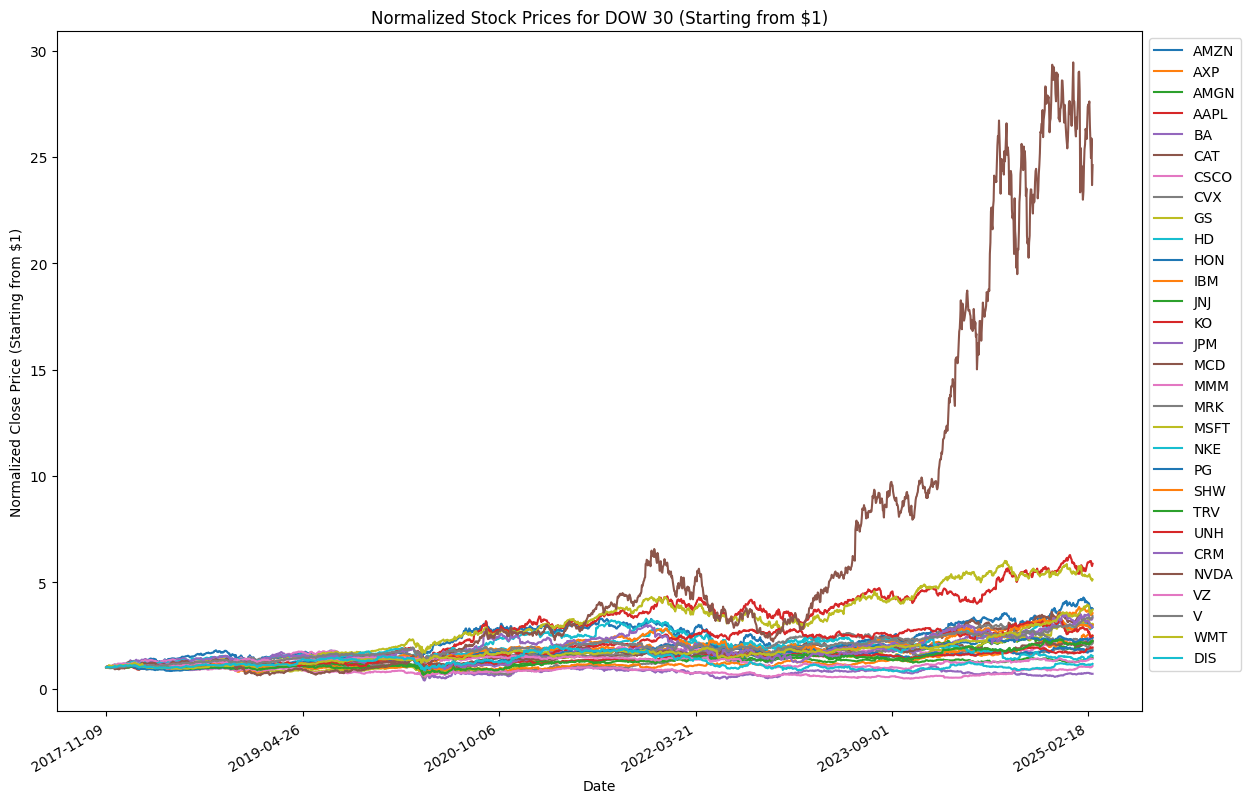

In [5]:
from config_tickers import DOW_30_TICKER, CRYPTO_TICKER

# 获取DOW_30_TICKER和CRYPTO_TICKER的列表

# 计算每个股票的归一化价格（以1美元为基准）
df['normalized_close'] = df.groupby('tic')['close'].transform(lambda x: x / x.iloc[0])

# 绘制DOW_30_TICKER股票走势
plt.figure(figsize=(14, 10))
for tic in DOW_30_TICKER:
    if tic in df['tic'].unique():
        plt.plot(df[df['tic'] == tic]['date'], df[df['tic'] == tic]['normalized_close'], label=tic)

plt.xlabel('Date')
plt.ylabel('Normalized Close Price (Starting from $1)')
plt.title('Normalized Stock Prices for DOW 30 (Starting from $1)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.show()


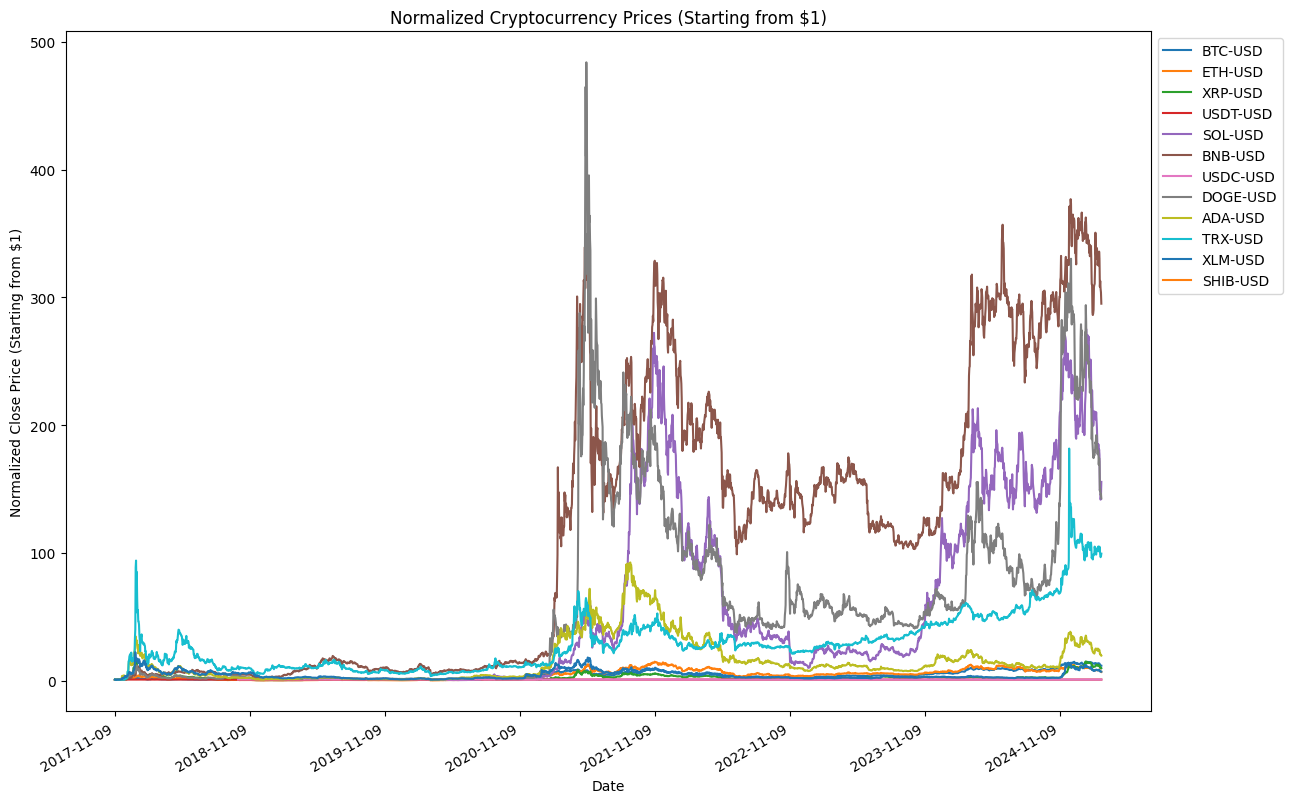

In [6]:

# 绘制CRYPTO_TICKER股票走势
plt.figure(figsize=(14, 10))
for tic in CRYPTO_TICKER:
    if tic in df['tic'].unique():
        plt.plot(df[df['tic'] == tic]['date'], df[df['tic'] == tic]['normalized_close'], label=tic)

plt.xlabel('Date')
plt.ylabel('Normalized Close Price (Starting from $1)')
plt.title('Normalized Cryptocurrency Prices (Starting from $1)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
#plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gcf().autofmt_xdate()
plt.show()

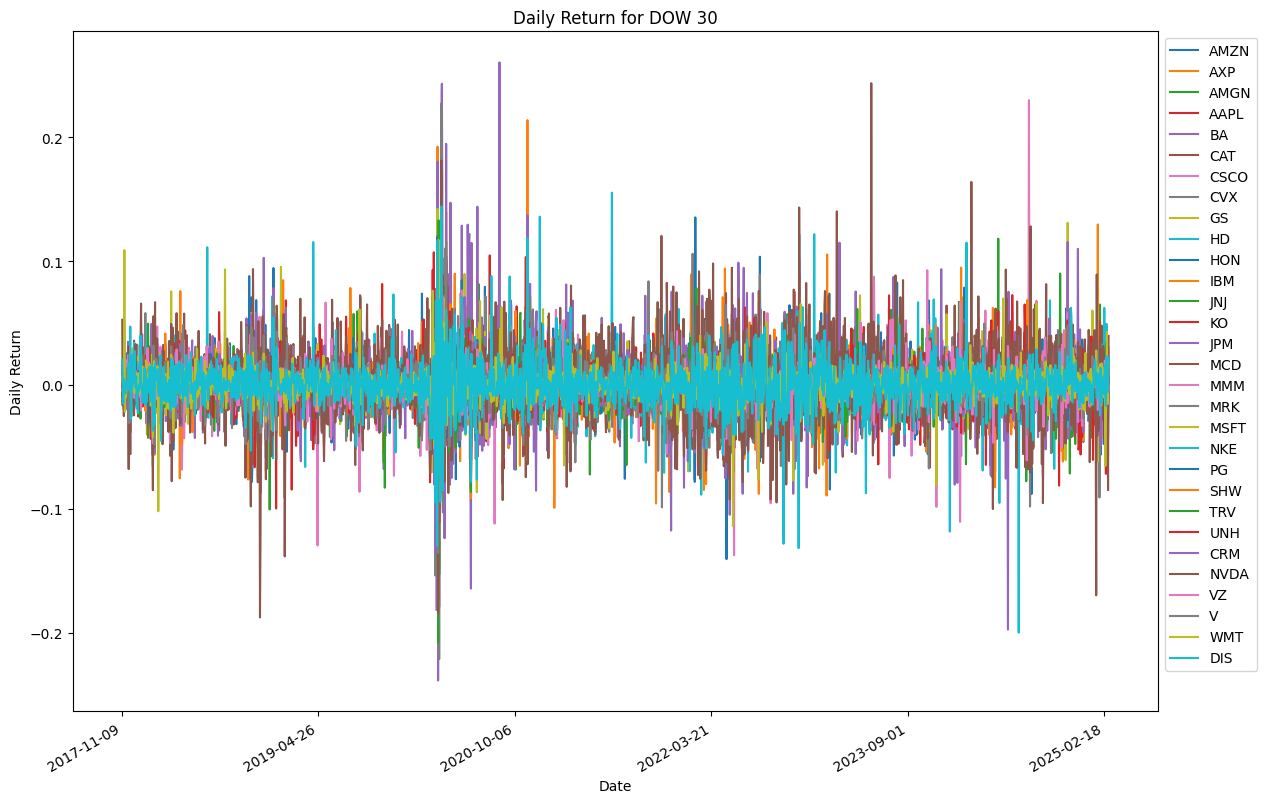

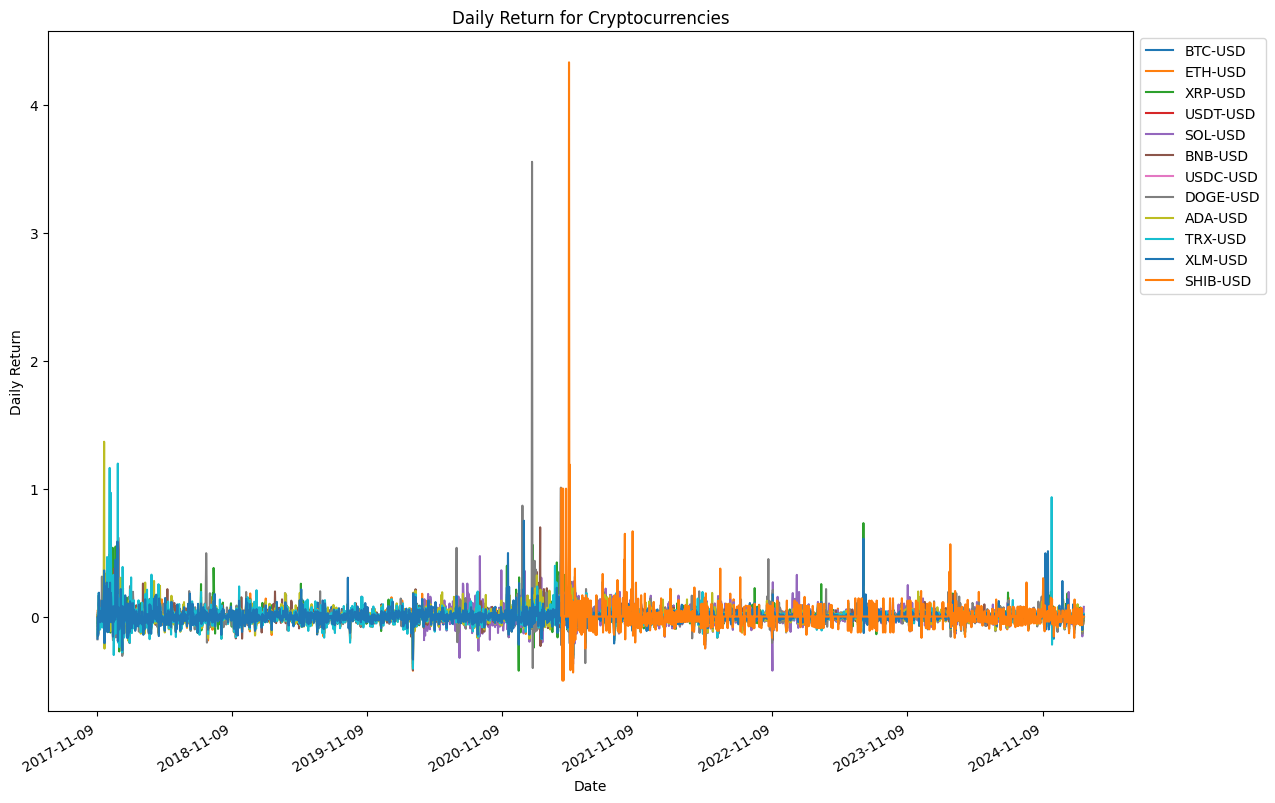

In [7]:
# 计算每个资产的每日增长率
df['daily_return'] = df.groupby('tic')['close'].pct_change()

# 绘制DOW_30_TICKER资产的增长率走势图
plt.figure(figsize=(14, 10))
for tic in DOW_30_TICKER:
    if tic in df['tic'].unique():
        plt.plot(df[df['tic'] == tic]['date'], df[df['tic'] == tic]['daily_return'], label=tic)

plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.title('Daily Return for DOW 30')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.show()

# 绘制CRYPTO_TICKER资产的增长率走势图
plt.figure(figsize=(14, 10))
for tic in CRYPTO_TICKER:
    if tic in df['tic'].unique():
        plt.plot(df[df['tic'] == tic]['date'], df[df['tic'] == tic]['daily_return'], label=tic)

plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.title('Daily Return for Cryptocurrencies')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()
plt.show()

<a id='4'></a>
# Part 4. Preprocess Data

Data preprocessing is a crucial step for training a high quality machine learning model. We need to check for missing data and do feature engineering in order to convert the data into a model-ready state.
* Add technical indicators. In practical trading, various information needs to be taken into account, for example the historical stock prices, current holding shares, technical indicators, etc. In this article, we demonstrate two trend-following technical indicators: "macd","boll_ub","boll_lb","rsi_30","cci_30","dx_30","close_30_sma","close_60_sma"
* Add turbulence index. Risk-aversion reflects whether an investor will choose to preserve the capital. It also influences one's trading strategy when facing different market volatility level. To control the risk in a worst-case scenario, such as financial crisis of 2007–2008, FinRL employs the financial turbulence index that measures extreme asset price fluctuation.

In [8]:
from lib.preprocessors import FeatureEngineer
fe = FeatureEngineer(
                    use_technical_indicator=True,
                    use_turbulence=False,
                    user_defined_feature = False)

df = fe.preprocess_data(df)
df.to_csv("./" + config.DATA_SAVE_DIR + "/data.csv")

c:\Users\Jiang\OneDrive - University of Southampton\Soton UG COURSE\Soton-24-25-2\ECON3037-Dissertation Research Project\Workings\My-UoS-Bsc-Dissertaion-Code\lib\preprocessors.py:190: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df = df.unstack().reindex(merged_closes.index).stack().reset_index()


Successfully added technical indicators


In [9]:
df

,date,tic,close,high,low,open,volume,day,normalized_close,daily_return,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma
0,2017-11-09,AAPL,41.182472,44.025002,43.285000,43.777500,1.179304e+08,3.0,1.000000,-0.003310,0.000000,41.307089,40.921545,0.000000,-66.666667,100.000000,41.182472,41.182472
1835,2017-11-09,ADA-USD,0.032053,0.035060,0.025006,0.025160,1.871620e+07,3.0,1.000000,-0.003310,0.000000,41.307089,40.921545,0.000000,-66.666667,100.000000,0.032053,0.032053
4504,2017-11-09,AMGN,138.740677,174.229996,171.309998,172.750000,2.005100e+06,3.0,1.000000,-0.003310,0.000000,41.307089,40.921545,0.000000,-66.666667,100.000000,138.740677,138.740677
6339,2017-11-09,AMZN,56.456501,56.480999,55.788502,56.298000,7.465400e+07,3.0,1.000000,-0.003310,0.000000,41.307089,40.921545,0.000000,-66.666667,100.000000,56.456501,56.456501
8174,2017-11-09,AXP,84.818558,94.660004,93.279999,94.339996,3.949800e+06,3.0,1.000000,-0.003310,0.000000,41.307089,40.921545,0.000000,-66.666667,100.000000,84.818558,84.818558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75816,2025-02-28,V,362.709991,364.000000,353.709991,354.709991,1.585730e+07,4.0,3.406430,0.019593,6.982644,360.693779,341.158196,70.654810,113.368440,55.397710,343.447082,328.377612
77651,2025-02-28,VZ,43.099998,43.759998,42.610001,43.430000,2.519750e+07,4.0,1.400065,-0.003929,0.966721,44.282731,38.434270,62.002326,132.847942,36.390838,40.725667,40.344924
79486,2025-02-28,WMT,98.610001,98.860001,97.169998,97.790001,2.545130e+07,4.0,3.707637,0.018804,0.231179,107.168736,93.406264,54.817549,-2.234826,4.504494,98.490334,95.591218
82155,2025-02-28,XLM-USD,0.286358,0.287716,0.252873,0.283120,3.042867e+08,4.0,7.168627,0.011433,-0.021396,0.366463,0.278042,41.300665,-178.146895,52.580565,0.335106,0.382927


In [10]:
train = df[(df.date >= TRAIN_START_DATE) & (df.date < TRAIN_END_DATE)]
test  = df[(df.date >= TEST_START_DATE) & (df.date < TEST_END_DATE)]
train.to_csv("./" + config.DATA_SAVE_DIR + "/train.csv")
test.to_csv("./" + config.DATA_SAVE_DIR + "/test.csv")

<a id='5'></a>
# Part 5. Design Environment

Considering the stochastic and interactive nature of the automated stock trading tasks, a financial task is modeled as a **Markov Decision Process (MDP)** problem. The training process involves observing stock price change, taking an action and reward's calculation to have the agent adjusting its strategy accordingly. By interacting with the environment, the trading agent will derive a trading strategy with the maximized rewards as time proceeds.

Our trading environments, based on OpenAI Gym framework, simulate live stock markets with real market data according to the principle of time-driven simulation.

The action space describes the allowed portfolio weights that the agent interacts with the environment. Each element in the portfolio weights vector is non-negative and no more than 100%. Also, the sum of elements in each portfolio weight should equal to 100%.

In [ ]:
import numpy as np
import pandas as pd
from gym.utils import seeding
import gym
from gym import spaces
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from stable_baselines3.common.vec_env import DummyVecEnv
from arch import arch_model
from scipy.stats import genpareto

class StockPortfolioEnv(gym.Env):
    """A portfolio allocation environment for OpenAI gym with CVaR risk constraint

    Attributes
    ----------
        df: DataFrame
            input data
        stock_dim : int
            number of unique stocks
        hmax : int
            maximum number of shares to trade
        initial_amount : int
            start money
        transaction_cost_pct: float
            transaction cost percentage per trade
        reward_scaling: float
            scaling factor for reward, good for training
        state_space: int
            the dimension of input features
        action_space: int
            equals stock dimension
        tech_indicator_list: list
            a list of technical indicator names
        turbulence_threshold: int
            a threshold to control risk aversion
        day: int
            an increment number to control date
        risk_aversion: float
            risk aversion parameter for CVaR in reward function
        confidence_level: float
            confidence level for CVaR calculation
        threshold_quantile: float
            threshold quantile for EVT in CVaR calculation
    """
    metadata = {'render.modes': ['human']}

    def __init__(self, 
                df,
                stock_dim,
                hmax,
                initial_amount,
                transaction_cost_pct,
                reward_scaling,
                state_space,
                action_space,
                tech_indicator_list,
                turbulence_threshold=None,
                lookback=252,
                day=0,
                risk_aversion=0.1,
                confidence_level=0.95,
                threshold_quantile=0.9):
        self.day = day
        self.lookback = lookback
        self.df = df
        self.stock_dim = stock_dim
        self.hmax = hmax
        self.initial_amount = initial_amount
        self.transaction_cost_pct = transaction_cost_pct
        self.reward_scaling = reward_scaling
        self.state_space = state_space
        self.action_space = action_space
        self.tech_indicator_list = tech_indicator_list
        self.turbulence_threshold = turbulence_threshold
        
        # 风险管理参数
        self.risk_aversion = risk_aversion
        self.confidence_level = confidence_level
        self.threshold_quantile = threshold_quantile
        self.return_memory = []  # 用于存储历史收益率
        self.cvar_history = []  # 用于存储CVaR历史

        # action_space normalization and shape is self.stock_dim
        self.action_space = spaces.Box(low=0, high=1, shape=(self.action_space,)) 
        
        # observation_space设置为技术指标加上其他观测值的维度
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.state_space+len(self.tech_indicator_list),))

        # load data from a pandas dataframe
        self.data = self.df.loc[self.day, :]
        # 初始化状态，不再包含协方差矩阵
        print(type(self.data))
        print(self.data.head())
        self.state = np.array([
            self.data.get(tech, pd.Series([0])).values.tolist()  
            for tech in self.tech_indicator_list
        ]).flatten()

        self.state = np.array([self.data[tech].values.tolist() for tech in self.tech_indicator_list]).flatten()
        self.terminal = False     
        
        # initialize state: initial portfolio return + individual stock return + individual weights
        self.portfolio_value = self.initial_amount

        # memorize portfolio value each step
        self.asset_memory = [self.initial_amount]
        # memorize portfolio return each step
        self.portfolio_return_memory = [0]
        self.actions_memory = [[1/self.stock_dim]*self.stock_dim]
        self.date_memory = [self.data.date.unique()[0]]
        
    def garch_evt_cvar(self, returns, confidence_level=None, threshold_quantile=None):
        """计算基于GARCH-EVT的CVaR"""
        if confidence_level is None:
            confidence_level = self.confidence_level
        if threshold_quantile is None:
            threshold_quantile = self.threshold_quantile
            
        # 如果历史数据不足，返回一个默认值
        if len(returns) < 30:
            return 0, 0
            
        try:
            # 1. 估计 GARCH(1,1) 模型
            model = arch_model(returns, vol='Garch', p=1, q=1, dist='t')
            res = model.fit(disp="off")
            
            # 2. 计算标准化残差（创新项）
            residuals = res.resid / res.conditional_volatility
            
            # 3. 设定 EVT 阈值，并拟合广义帕累托分布 (GPD)
            threshold = np.quantile(residuals, threshold_quantile)
            excess_losses = residuals[residuals > threshold] - threshold  # 超过阈值的极端值
            
            if len(excess_losses) < 10:  # 如果极端值太少，使用传统方法
                var_evt = np.quantile(returns, 1-confidence_level)
                cvar_evt = np.mean(returns[returns <= var_evt])
                return var_evt, cvar_evt
            
            # 拟合 GPD
            shape, loc, scale = genpareto.fit(excess_losses)
            
            # 4. 计算 VaR
            var_evt = threshold + (scale / shape) * ((1 - confidence_level) ** -shape - 1)
            
            # 5. 计算 CVaR
            cvar_evt = var_evt / (1 - shape) + (scale - shape * threshold) / ((1 - shape) * (1 - confidence_level))
            
            return var_evt, cvar_evt
            
        except:
            # 如果GARCH-EVT方法失败，回退到传统方法
            var_trad = np.quantile(returns, 1-confidence_level)
            cvar_trad = np.mean(returns[returns <= var_trad])
            return var_trad, cvar_trad
        
    def step(self, actions):
        self.terminal = self.day >= len(self.df.index.unique())-1

        if self.terminal:
            df = pd.DataFrame(self.portfolio_return_memory)
            df.columns = ['daily_return']
            plt.plot(df.daily_return.cumsum(),'r')
            plt.savefig('results/cumulative_reward.png')
            plt.close()
            
            plt.plot(self.portfolio_return_memory,'r')
            plt.savefig('results/rewards.png')
            plt.close()
            
            # 绘制CVaR历史
            if len(self.cvar_history) > 0:
                plt.plot(self.cvar_history, 'b')
                plt.savefig('results/cvar_history.png')
                plt.close()

            print("=================================")
            print("begin_total_asset:{}".format(self.asset_memory[0]))           
            print("end_total_asset:{}".format(self.portfolio_value))

            df_daily_return = pd.DataFrame(self.portfolio_return_memory)
            df_daily_return.columns = ['daily_return']
            if df_daily_return['daily_return'].std() != 0:
                sharpe = (252**0.5)*df_daily_return['daily_return'].mean()/ \
                       df_daily_return['daily_return'].std()
                print("Sharpe: ", sharpe)
                
            # 计算最终的CVaR
            if len(self.return_memory) > 30:
                _, final_cvar = self.garch_evt_cvar(np.array(self.return_memory))
                print("Final CVaR: ", final_cvar)
                
            print("=================================")
            
            return self.state, self.reward, self.terminal, {}

        else:
            weights = self.softmax_normalization(actions) 
            self.actions_memory.append(weights)
            last_day_memory = self.data

            # load next state
            self.day += 1
            self.data = self.df.loc[self.day, :]
            # 更新状态，不再包含协方差矩阵
            self.state = np.array([self.data[tech].values.tolist() for tech in self.tech_indicator_list]).flatten()
            
            # 计算投资组合收益率
            portfolio_return = sum(((self.data.close.values / last_day_memory.close.values)-1)*weights)
            log_portfolio_return = np.log(sum((self.data.close.values / last_day_memory.close.values)*weights))
            
            # 存储收益率用于风险计算
            self.return_memory.append(portfolio_return)
            
            # 更新投资组合价值
            new_portfolio_value = self.portfolio_value*(1+portfolio_return)
            self.portfolio_value = new_portfolio_value

            # 保存到内存
            self.portfolio_return_memory.append(portfolio_return)
            self.date_memory.append(self.data.date.unique()[0])            
            self.asset_memory.append(new_portfolio_value)

            # 计算CVaR（当有足够数据时）
            cvar = 0
            if len(self.return_memory) > 30:
                _, cvar = self.garch_evt_cvar(np.array(self.return_memory))
                self.cvar_history.append(cvar)
            
            # 包含CVaR惩罚的奖励函数
            # 正向奖励是投资组合价值，负向惩罚是CVaR
            self.reward = new_portfolio_value - self.risk_aversion * cvar * self.portfolio_value
            self.reward = self.reward * self.reward_scaling
            
            return self.state, self.reward, self.terminal, {}

    def reset(self):
        self.asset_memory = [self.initial_amount]
        self.day = 0
        self.data = self.df.loc[self.day, :]
        # 初始化状态，不再包含协方差矩阵
        self.state = np.array([self.data[tech].values.tolist() for tech in self.tech_indicator_list]).flatten()
        self.portfolio_value = self.initial_amount
        self.terminal = False 
        self.portfolio_return_memory = [0]
        self.actions_memory = [[1/self.stock_dim]*self.stock_dim]
        self.date_memory = [self.data.date.unique()[0]]
        self.return_memory = []
        self.cvar_history = []
        return self.state
    
    def render(self, mode='human'):
        return self.state
        
    def softmax_normalization(self, actions):
        numerator = np.exp(actions)
        denominator = np.sum(np.exp(actions))
        softmax_output = numerator/denominator
        return softmax_output
    
    def save_asset_memory(self):
        date_list = self.date_memory
        portfolio_return = self.portfolio_return_memory
        df_account_value = pd.DataFrame({'date':date_list, 'daily_return':portfolio_return})
        return df_account_value

    def save_action_memory(self):
        # date and close price length must match actions length
        date_list = self.date_memory
        df_date = pd.DataFrame(date_list)
        df_date.columns = ['date']
        
        action_list = self.actions_memory
        df_actions = pd.DataFrame(action_list)
        df_actions.columns = self.data.tic.values
        df_actions.index = df_date.date
        return df_actions
        
    def save_risk_memory(self):
        """保存风险指标历史"""
        if len(self.cvar_history) > 0:
            # 只保存有CVaR数据的日期（至少需要30天数据）
            date_list = self.date_memory[30:]
            df_risk = pd.DataFrame({'date': date_list, 'cvar': self.cvar_history})
            return df_risk
        return pd.DataFrame()

    def _seed(self, seed=None):
        self.np_random, seed = seeding.np_random(seed)
        return [seed]

    def get_sb_env(self):
        e = DummyVecEnv([lambda: self])
        obs = e.reset()
        return e, obs

In [16]:
stock_dimension = len(train.tic.unique())
state_space = stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")
tech_indicator_list = config.INDICATORS
feature_dimension = len(tech_indicator_list)
print(f"Feature Dimension: {feature_dimension}")

Stock Dimension: 42, State Space: 42
Feature Dimension: 8


In [17]:
env_kwargs = {
    "hmax": 100, 
    "initial_amount": 1000000, 
    "transaction_cost_pct": 0.001, 
    "state_space": state_space, 
    "stock_dim": stock_dimension, 
    "tech_indicator_list": tech_indicator_list, 
    "action_space": stock_dimension, 
    "reward_scaling": 1e-1,
    "risk_aversion":0.1,  # 风险厌恶系数
    "confidence_level":0.95,  # VaR/CVaR 置信水平
    "threshold_quantile":0.9
}

e_train_gym = StockPortfolioEnv(df = train, **env_kwargs)

<class 'pandas.core.series.Series'>
date     2017-11-09
tic            AAPL
close     41.182472
high      44.025002
low          43.285
Name: 0, dtype: object


AttributeError: 'numpy.float64' object has no attribute 'values'

In [ ]:
env_train, _ = e_train_gym.get_sb_env()
print(type(env_train))